# Notebook — Individual Steps

Runs each step from [overview.md](overview.md) individually using `dqm_ml_job.cli.run()` with inline Python dict configs. Each step: builds the config, calls `run()`, loads the output parquet, and adds a matplotlib visualization.


In [59]:
from dqm_ml_job.cli import run

import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


def _strip_examples(d):
    """Recursively strip "examples/" prefix from path values.
    Notebook runs in examples/notebooks/, YAML configs assume repo root.
    """
    if isinstance(d, dict):
        return {k: (_strip_examples(v) if k != "path" else "../" + v.removeprefix("examples/")) for k, v in d.items()}
    if isinstance(d, list):
        return [_strip_examples(i) for i in d]
    return d


VISUAL_FEATURES_PATH = "../outputs/story_visual_features.parquet"


def _load_config(path):
    """Load YAML config and adjust paths for notebook location."""
    cfg = yaml.safe_load(Path(path).read_text())
    return _strip_examples(cfg)


# Verify data files exist
data_dir = Path("../data")
if not (data_dir / "samples_with_images.parquet").exists():
    print("Run `python script/generate_data.py` first")

## 1. Visual Features

Extracts per-image quality indicators (luminosity, contrast, blur, entropy) from synthetic 32×32 images.


In [60]:
# ---- Config ----
config = _load_config("../config/scenario/visual_features.yaml")
run(config)

df = pd.read_parquet(VISUAL_FEATURES_PATH)
print("First 5 rows:")
print(df.head(5).to_markdown(index=False))
print("\nAggregated by source:")
feature_cols = [
    "image_bytes_luminosity",
    "image_bytes_contrast",
    "image_bytes_blur",
    "image_bytes_entropy",
]
agg = df.groupby("source")[feature_cols].mean()
print(agg.to_markdown())

selection: 100%|██████████| 1/1 [00:00<00:00,  4.70it/s]

First 5 rows:
|   sample_id |   class_id | class_name   | source   |   image_bytes_luminosity |   image_bytes_contrast |   image_bytes_blur |   image_bytes_entropy |
|------------:|-----------:|:-------------|:---------|-------------------------:|-----------------------:|-------------------:|----------------------:|
|           0 |          2 | giraffe      | reserve  |                 0.344522 |               0.181848 |           0.654904 |               4.98741 |
|           1 |          2 | giraffe      | safari   |                 0.503512 |               0.189889 |           0.763345 |               5.13467 |
|           2 |          1 | lion         | safari   |                 0.508238 |               0.202693 |           0.823988 |               5.16956 |
|           3 |          0 | elephant     | safari   |                 0.534855 |               0.196135 |           0.839806 |               5.11685 |
|           4 |          2 | giraffe      | reserve  |                 0.3

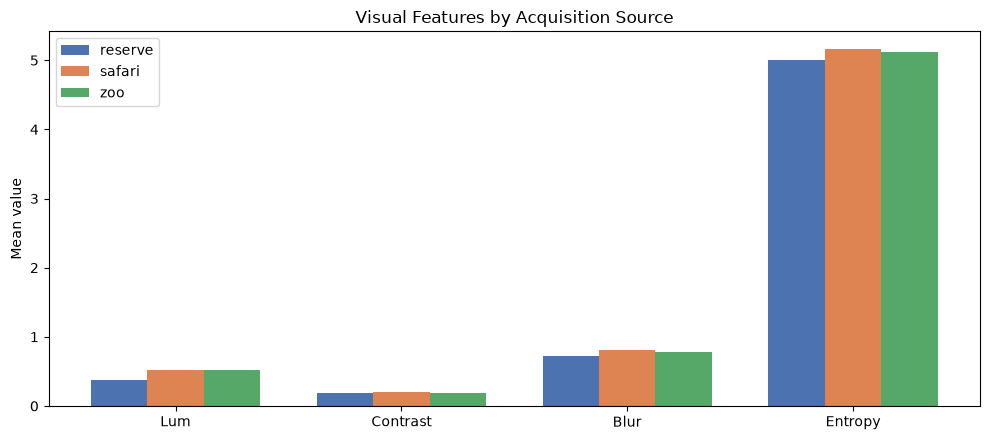

In [61]:
df = pd.read_parquet(VISUAL_FEATURES_PATH)
feature_cols = [
    "image_bytes_luminosity",
    "image_bytes_contrast",
    "image_bytes_blur",
    "image_bytes_entropy",
]
agg = df.groupby("source")[feature_cols].mean()

fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(feature_cols))
w = 0.25
colors = ["#4C72B0", "#DD8452", "#55A868"]
short_labels = ["Lum", "Contrast", "Blur", "Entropy"]
for i, src in enumerate(agg.index):
    ax.bar(x + i * w, [agg.loc[src, c] for c in feature_cols], w, label=src, color=colors[i])
ax.set_xticks(x + w)
ax.set_xticklabels(short_labels)
ax.set_ylabel("Mean value")
ax.set_title("Visual Features by Acquisition Source")
ax.legend()
plt.tight_layout()
plt.show()

## 2. Embeddings

Computes 512-d ResNet-18 embedding vectors for every image.


In [62]:
# ---- Config ----
config = _load_config("../config/scenario/embeddings.yaml")
run(config)

df = pd.read_parquet("../outputs/story_embeddings.parquet")
# print(df.head(5).to_markdown(index=False))

selection: 100%|██████████| 1/1 [00:01<00:00,  1.77s/it]


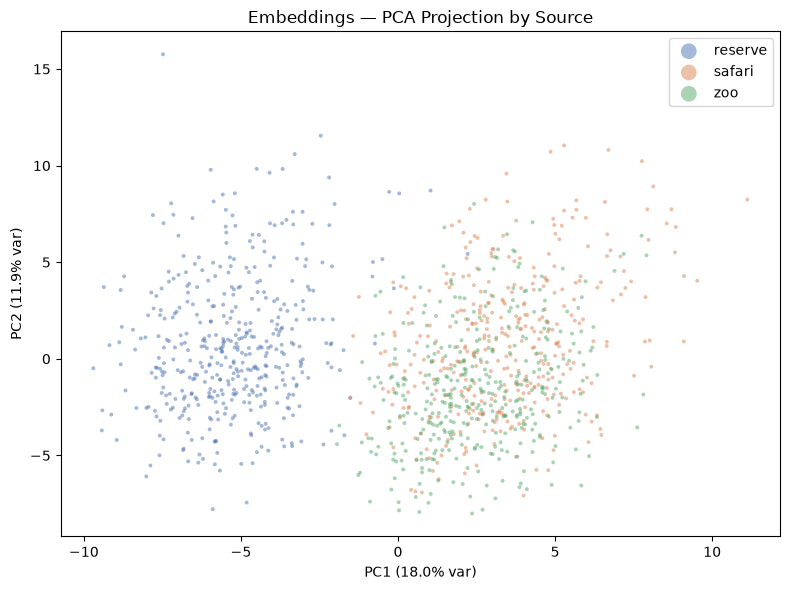

In [63]:
from sklearn.decomposition import PCA

df = pd.read_parquet("../outputs/story_embeddings.parquet")
# Reduce 512-d ResNet-18 embeddings to 2 components for scatter-plot visualization
emb = np.array(df["image_bytes_embedding"].to_list())

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(emb)
vp = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(8, 6))
sources = df["source"].unique()
colors = ["#4C72B0", "#DD8452", "#55A868"]
for src, c in zip(sources, colors):
    mask = df["source"] == src
    ax.scatter(coords[mask, 0], coords[mask, 1], c=c, label=src, alpha=0.5, s=8, edgecolors="none")
    ax.set_xlabel(f"PC1 ({vp[0]:.1%} var)")
    ax.set_ylabel(f"PC2 ({vp[1]:.1%} var)")
    ax.set_title("Embeddings — PCA Projection by Source")
    ax.legend(markerscale=4)
plt.tight_layout()
plt.show()

## 3. Completeness

Checks every sample for missing values in the visual-feature columns (1200 rows, 4 features).


In [64]:
# ---- Config ----
config = _load_config("../config/scenario/completeness.yaml")
run(config)

df = pd.read_parquet("../outputs/story_completeness.parquet")
print(df.to_markdown(index=False))

selection: 100%|██████████| 1/1 [00:00<00:00, 232.87it/s]

| selection      |   completeness_sample_id |   completeness_image_bytes_luminosity |   completeness_image_bytes_contrast |   completeness_image_bytes_blur |   completeness_image_bytes_entropy |   completeness_overall |
|:---------------|-------------------------:|--------------------------------------:|------------------------------------:|--------------------------------:|-----------------------------------:|-----------------------:|
| source_dataset |                        1 |                                     1 |                                   1 |                               1 |                                  1 |                      1 |


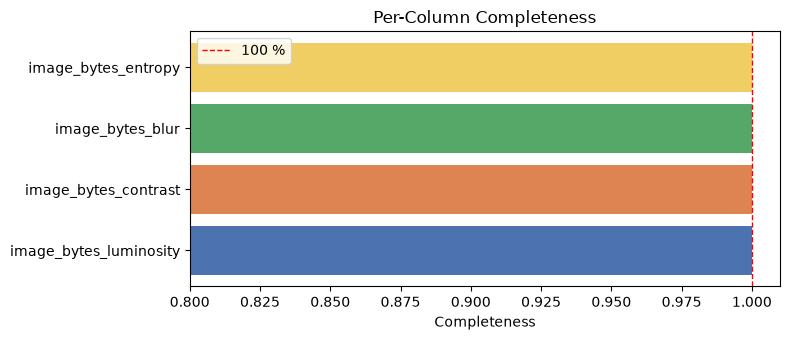

In [65]:
df = pd.read_parquet("../outputs/story_completeness.parquet")
cols = [
    "completeness_image_bytes_luminosity",
    "completeness_image_bytes_contrast",
    "completeness_image_bytes_blur",
    "completeness_image_bytes_entropy",
]
vals = [df[col].iloc[0] for col in cols]

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.barh(
    ["image_bytes_luminosity", "image_bytes_contrast", "image_bytes_blur", "image_bytes_entropy"],
    vals,
    color=["#4C72B0", "#DD8452", "#55A868", "#F1CE63"],
)
ax.axvline(1.0, color="red", ls="--", lw=1, label="100 %")
ax.set_xlim(0.8, 1.01)
ax.set_xlabel("Completeness")
ax.set_title("Per-Column Completeness")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Diversity

Measures class balance and category spread using Simpson, Gini, Shannon, and Richness indices on the visual features dataset (output of step 3), grouped by class and source.


In [66]:
# ---- Config ----
config = _load_config("../config/scenario/diversity.yaml")
run(config)

df = pd.read_parquet("../outputs/story_diversity.parquet")
print(df.to_markdown(index=False))

selection: 100%|██████████| 1/1 [00:00<00:00, 181.21it/s]

| selection      |   class_name_richness |   class_name_shannon |   class_name_gini |   class_name_simpson |   source_richness |   source_shannon |   source_gini |   source_simpson |
|:---------------|----------------------:|---------------------:|------------------:|---------------------:|------------------:|-----------------:|--------------:|-----------------:|
| source_dataset |                     4 |              1.38589 |          0.749799 |             0.750424 |                 3 |          1.09689 |      0.665504 |         0.666059 |


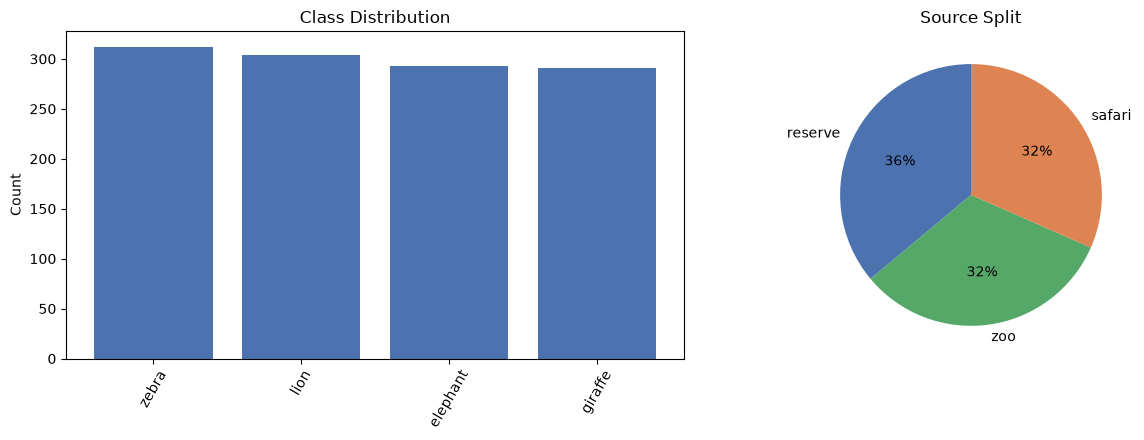

In [67]:
raw = pd.read_parquet(VISUAL_FEATURES_PATH)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# Left bar: class frequency across all sources
class_counts = raw["class_name"].value_counts()
ax1.bar(class_counts.index, class_counts.values, color="#4C72B0")
ax1.set_title("Class Distribution")
ax1.tick_params(axis="x", rotation=60)
ax1.set_ylabel("Count")

# Right pie: proportion of samples per source
source_counts = raw["source"].value_counts()
colors_pt = ["#4C72B0", "#55A868", "#DD8452"]
ax2.pie(source_counts.values, labels=source_counts.index, autopct="%1.0f%%", colors=colors_pt, startangle=90)
ax2.set_title("Source Split")

plt.tight_layout()
plt.show()

## 5. Representativeness

Tests whether luminosity, contrast, blur, and entropy (from step 3) follow a normal distribution using chi-square, KS, entropy, and GRTE.


In [68]:
# ---- Config ----
config = _load_config("../config/scenario/representativeness.yaml")
run(config)

df = pd.read_parquet("../outputs/story_representativeness.parquet")

# Compact summary table
rows = []
for col in ["image_bytes_luminosity", "image_bytes_contrast", "image_bytes_blur", "image_bytes_entropy"]:
    rows.append(
        {
            "column": col,
            "chi-square p": df[f"{col}_chi-square_p_value"].iloc[0],
            "chi-square": df[f"{col}_chi-square_interpretation"].iloc[0],
            "KS p": df[f"{col}_kolmogorov-smirnov_p_value"].iloc[0],
            "KS": df[f"{col}_kolmogorov-smirnov_interpretation"].iloc[0],
            "GRTE": df[f"{col}_grte_grte_value"].iloc[0],
            "GRTE int.": df[f"{col}_grte_interpretation"].iloc[0],
        }
    )
summary = pd.DataFrame(rows)
print(summary.to_markdown(index=False))

selection: 100%|██████████| 1/1 [00:00<00:00, 58.88it/s]

| column                 |   chi-square p | chi-square                   |        KS p | KS                           |     GRTE | GRTE int.               |
|:-----------------------|---------------:|:-----------------------------|------------:|:-----------------------------|---------:|:------------------------|
| image_bytes_luminosity |   0            | does_not_follow_distribution | 8.67217e-05 | does_not_follow_distribution | 0.243668 | low_representativeness  |
| image_bytes_contrast   |   0.0160326    | does_not_follow_distribution | 0.116618    | follows_distribution         | 0.971582 | high_representativeness |
| image_bytes_blur       |   0.382635     | follows_distribution         | 0.653867    | follows_distribution         | 0.983415 | high_representativeness |
| image_bytes_entropy    |   3.25933e-170 | does_not_follow_distribution | 0.00470862  | does_not_follow_distribution | 0.451111 | low_representativeness  |


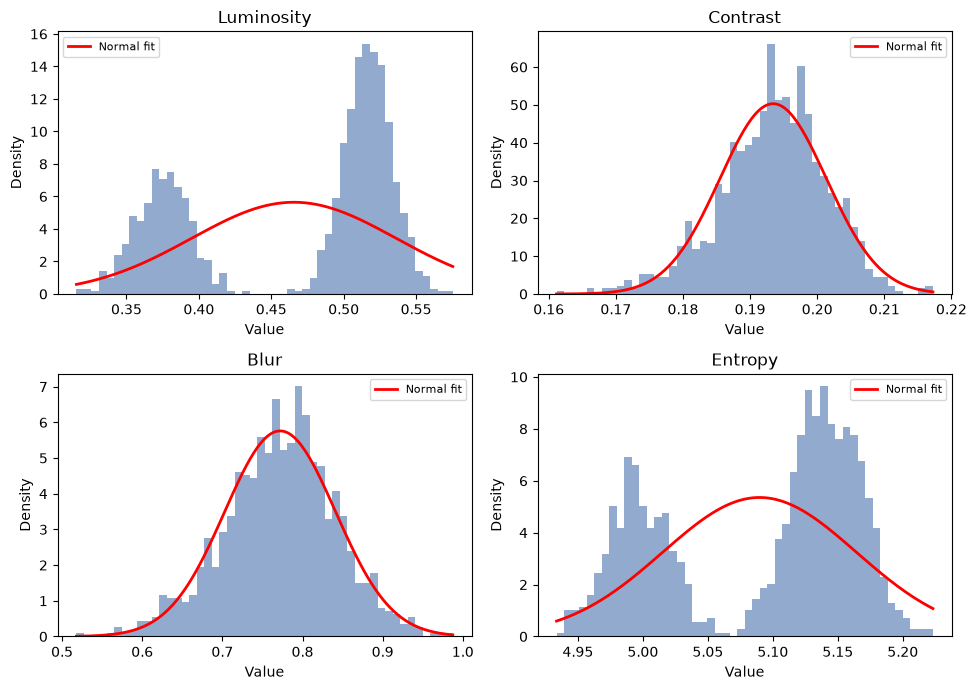

In [69]:
raw = pd.read_parquet(VISUAL_FEATURES_PATH)
columns = ["image_bytes_luminosity", "image_bytes_contrast", "image_bytes_blur", "image_bytes_entropy"]
short = {k: k.replace("image_bytes_", "") for k in columns}

# Overlay normal-fit curves (red dashed) on per-feature histograms
fig, axes = plt.subplots(2, 2, figsize=(10, 7))

for ax, col in zip(axes.ravel(), columns):
    vals = raw[col].dropna()
    ax.hist(vals, bins=50, density=True, alpha=0.6, color="#4C72B0")
    mu, std = vals.mean(), vals.std()
    x = np.linspace(vals.min(), vals.max(), 200)
    pdf = (1 / (std * np.sqrt(2 * np.pi))) * np.exp(-((x - mu) ** 2) / (2 * std**2))
    ax.plot(x, pdf, "r-", lw=2, label="Normal fit")
    ax.set_title(short[col].title())
    ax.set_xlabel("Value")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 6. Domain Gap (Split)

Splits the image dataset by `source` (zoo, safari, reserve) and computes pairwise FID between every pair of subsets.


In [70]:
# ---- Config ----
config = _load_config("../config/scenario/domain_gap_with_split.yaml")
run(config)

df = pd.read_parquet("../outputs/story_gap_split.parquet")
print(df.to_markdown(index=False))

selection: 100%|██████████| 3/3 [00:02<00:00,  1.16it/s]


|     fid | selection_source   | selection_target   | source_target                  |
|--------:|:-------------------|:-------------------|:-------------------------------|
| 28.2746 | animals_zoo        | animals_safari     | animals_zoo_animals_safari     |
| 89.3335 | animals_zoo        | animals_reserve    | animals_zoo_animals_reserve    |
| 97.0944 | animals_safari     | animals_reserve    | animals_safari_animals_reserve |


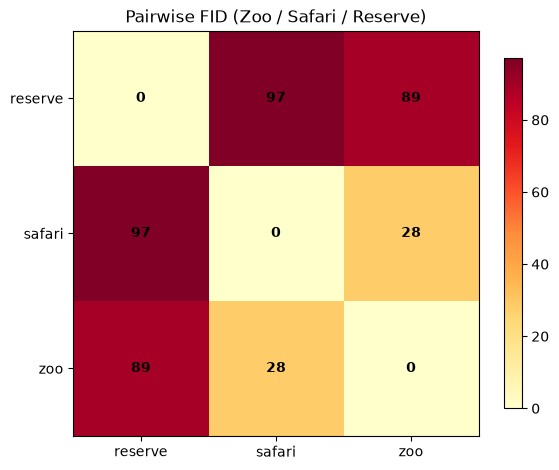

In [71]:
df = pd.read_parquet("../outputs/story_gap_split.parquet")
# Build symmetric FID matrix from pairwise results
sel_names = sorted(set(df["selection_source"]) | set(df["selection_target"]))
sources = list(sel_names)
labels = [s.split("_", 1)[-1] for s in sel_names]
n = len(sources)
matrix = np.full((n, n), np.nan)
for _, r in df.iterrows():
    i = sources.index(r["selection_source"])
    j = sources.index(r["selection_target"])
    matrix[i, j] = r["fid"]
    matrix[j, i] = r["fid"]
np.fill_diagonal(matrix, 0)

# Heatmap: darker = larger distribution shift between sources
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(matrix, cmap="YlOrRd", aspect="equal")
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
for i in range(n):
    for j in range(n):
        val = matrix[i, j]
        color = "white" if val > 200 else "black"
        ax.text(j, i, f"{val:.0f}", ha="center", va="center", color=color, fontweight="bold")
ax.set_title("Pairwise FID (Zoo / Safari / Reserve)")
plt.colorbar(im, shrink=0.8)
plt.tight_layout()
plt.show()

## 7. Domain Gap (Filter)

Filters to safari and reserve sources with two separate loaders and measures MMD-RBF between them.


In [72]:
# ---- Config ----
config = _load_config("../config/scenario/domain_gap_with_filter.yaml")
run(config)

df = pd.read_parquet("../outputs/story_gap_filter.parquet")
print(df.to_markdown(index=False))

selection: 100%|██████████| 2/2 [00:01<00:00,  1.41it/s]


|    mmd_rbf | selection_source   | selection_target   | source_target   |
|-----------:|:-------------------|:-------------------|:----------------|
| 0.00497188 | safari             | reserve            | safari_reserve  |


## 8. Domain Gap (Split + Filter)

Filters to zoo only, then splits by all class_name values (elephant, giraffe, lion, zebra). Wasserstein-1D measures distribution shift between every class pair, producing a 4×4 heatmap of pairwise embedding distances within a single controlled environment.


In [73]:
# ---- Config ----
config = _load_config("../config/scenario/domain_gap_with_split_and_filter.yaml")
run(config)

df = pd.read_parquet("../outputs/story_gap_split_filter.parquet")
print(df.to_markdown(index=False))

selection: 100%|██████████| 4/4 [00:01<00:00,  3.67it/s]

|   wasserstein_1d | selection_source   | selection_target   | source_target            |
|-----------------:|:-------------------|:-------------------|:-------------------------|
|        0.0638355 | zoo_giraffe        | zoo_lion           | zoo_giraffe_zoo_lion     |
|        0.0526164 | zoo_giraffe        | zoo_elephant       | zoo_giraffe_zoo_elephant |
|        0.0986016 | zoo_giraffe        | zoo_zebra          | zoo_giraffe_zoo_zebra    |
|        0.0606734 | zoo_lion           | zoo_elephant       | zoo_lion_zoo_elephant    |
|        0.0877994 | zoo_lion           | zoo_zebra          | zoo_lion_zoo_zebra       |
|        0.0654039 | zoo_elephant       | zoo_zebra          | zoo_elephant_zoo_zebra   |


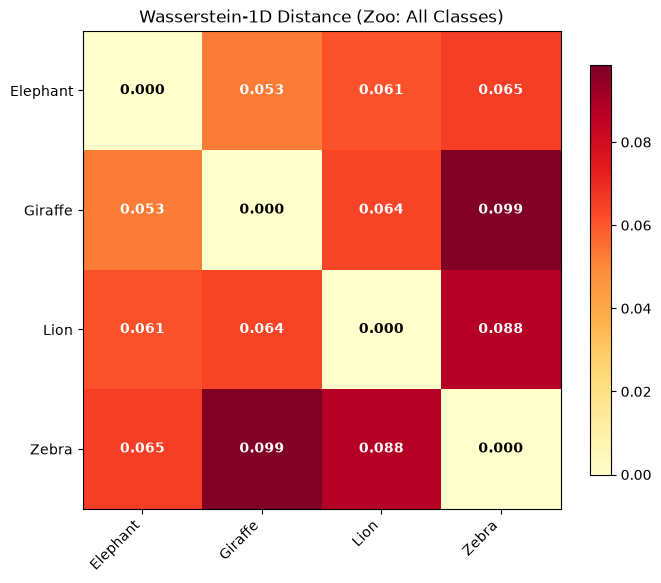

In [74]:
df = pd.read_parquet("../outputs/story_gap_split_filter.parquet")
# Build 4x4 Wasserstein-1D matrix, one row/col per animal class
classes = ["elephant", "giraffe", "lion", "zebra"]
labels = ["Elephant", "Giraffe", "Lion", "Zebra"]
matrix = np.full((4, 4), np.nan)
for _, r in df.iterrows():
    src_cls = r["selection_source"].split("_")[-1]
    tgt_cls = r["selection_target"].split("_")[-1]
    i = classes.index(src_cls)
    j = classes.index(tgt_cls)
    matrix[i, j] = r["wasserstein_1d"]
    matrix[j, i] = r["wasserstein_1d"]
np.fill_diagonal(matrix, 0)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(matrix, cmap="YlOrRd", aspect="equal")
ax.set_xticks(range(4))
ax.set_yticks(range(4))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticklabels(labels)
# Heatmap of embedding-distance between class pairs (same source)
for i in range(4):
    for j in range(4):
        val = matrix[i, j]
        color = "white" if val > 0.05 else "black"
        ax.text(j, i, f"{val:.3f}", ha="center", va="center", color=color, fontweight="bold")
ax.set_title("Wasserstein-1D Distance (Zoo: All Classes)")
plt.colorbar(im, shrink=0.8)
plt.tight_layout()
plt.show()